In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
## define BN
def batch_norm(X,gamma,beta,moving_mean,moving_var,eps,momentum):
    ## 判断当前模型
    if not torch.is_grad_enabled():
        X_hat = (X - moving_mean)/torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2,4)
        if len(X.shape) == 2:
            mean = X.mean(dim=0)
            var = ((X - mean)**2).mean(dim=0)
        else:
            mean = X.mean(dim=(0,2,3),keepdim=True)
            var = ((X -mean)**2).mean(dim=(0,2,3),keepdim=True)
        X_hat = (X-mean)/torch.sqrt(var+eps)
        moving_mean = momentum * moving_mean + (1-momentum)*mean
        moving_var = momentum * moving_var + (1-momentum)*var
    Y = gamma*X_hat + beta
    return Y,moving_mean.data,moving_var.data

In [3]:
## 封装为layer
class BatchNorm(nn.Module):
    def __init__(self,num_features,num_dims):
        super().__init__()
        if num_dims ==2:
            shape =(1,num_features)
        else:
            shape = (1,num_features,1,1)
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)

    def forward(self,X):
        if self.moving_mean.device != X.device:
            self.moving_mean = self.moving_mean.to(X.device)
            self.moving_var = self.moving_var.to(X.device)
        Y,self.moving_mean,self.moving_var = batch_norm(X,self.gamma,self.beta,self.moving_mean,self.moving_var,eps=1e-5,momentum=0.9)
        return Y

In [4]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), BatchNorm(6, num_dims=4), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), BatchNorm(16, num_dims=4), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2), nn.Flatten(),
    nn.Linear(16*4*4, 120), BatchNorm(120, num_dims=2), nn.Sigmoid(),
    nn.Linear(120, 84), BatchNorm(84, num_dims=2), nn.Sigmoid(),
    nn.Linear(84, 10)
)

In [5]:
lr, num_epochs, batch_size = 1.0, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

In [6]:
## 将模型放到 M5 GPU
## 定义 MPS 设备
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"使用设备: {device}")

## 将模型移动到 M5 GPU
net.to(device)

使用设备: mps


Sequential(
  (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (1): BatchNorm()
  (2): Sigmoid()
  (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (4): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (5): BatchNorm()
  (6): Sigmoid()
  (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Linear(in_features=256, out_features=120, bias=True)
  (10): BatchNorm()
  (11): Sigmoid()
  (12): Linear(in_features=120, out_features=84, bias=True)
  (13): BatchNorm()
  (14): Sigmoid()
  (15): Linear(in_features=84, out_features=10, bias=True)
)

In [7]:
def evaluate_accuracy_gpu(net, data_iter, device=None):
    if isinstance(net, nn.Module):
        net.eval() # 设置为评估模式
        if not device:
            device = next(iter(net.parameters())).device # 自动获取模型所在设备
    metric = d2l.Accumulator(2) # 正确预测数，总预测数
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device) 
            metric.add(d2l.accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [8]:
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
   
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
            
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    
    timer, num_batches = d2l.Timer(), len(train_iter)
    
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = d2l.Accumulator(3)
        net.train() # 切换为训练模式
        
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            # 将数据移动到 MPS 设备
            X, y = X.to(device), y.to(device)
            
          
            y_hat = net(X)
            l = loss(y_hat, y)
            
            l.backward()
            optimizer.step()
            
            with torch.no_grad():
                # 累加当前批次的损失总和、正确预测数、样本数
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            
      
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            
         
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        
        
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
        
        
        print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
              f'test acc {test_acc:.3f}')
        # ============================================
        
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')


loss 0.244, train acc 0.909, test acc 0.889
12851.2 examples/sec on mps


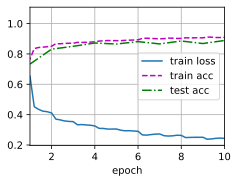

In [9]:
train_ch6(net, train_iter, test_iter, num_epochs, lr, torch.device("mps"))

In [ ]:
## 使用 API调用 BatchNorm
net = nn.Sequential(
nn.Conv2d(1, 6, kernel_size=5), nn.BatchNorm2d(6), nn.Sigmoid(),
nn.AvgPool2d(kernel_size=2, stride=2),
nn.Conv2d(6, 16, kernel_size=5), nn.BatchNorm2d(16), nn.Sigmoid(),
nn.AvgPool2d(kernel_size=2, stride=2), nn.Flatten(),
nn.Linear(256, 120), nn.BatchNorm1d(120), nn.Sigmoid(),
nn.Linear(120, 84), nn.BatchNorm1d(84), nn.Sigmoid(),
nn.Linear(84, 10))

loss 0.249, train acc 0.907, test acc 0.892
21425.6 examples/sec on mps


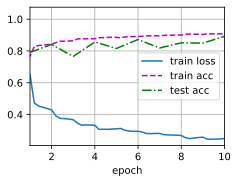

In [11]:
train_ch6(net, train_iter, test_iter, num_epochs, lr, torch.device("mps"))